# Clustering Analysis: Water Potability Dataset
## Analisis Clustering untuk Kualitas Air

**Tujuan:** Melakukan analisis clustering unsupervised pada dataset kualitas air untuk mengidentifikasi pola dan kelompok sampel air berdasarkan karakteristik fisika-kimianya.

**Dataset:** water_potability.csv - 3.276 sampel air dengan 9 fitur karakteristik.

---
## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

---
## LANGKAH 1: EKSPLORASI DATA (EDA)

### 1.1 Shape, Tipe Data, dan 5 Baris Pertama

In [2]:
# Load dataset
df = pd.read_csv('data/water_potability.csv')

# Shape dataset
print("=" * 60)
print("SHAPE DATASET")
print("=" * 60)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# Tipe data
print("\n" + "=" * 60)
print("TIPE DATA")
print("=" * 60)
print(df.dtypes)

# 5 baris pertama
print("\n" + "=" * 60)
print("5 BARIS PERTAMA DATASET")
print("=" * 60)
print(df.head())

SHAPE DATASET
Jumlah baris: 3276
Jumlah kolom: 10

TIPE DATA
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

5 BARIS PERTAMA DATASET
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.3

### 1.2 Missing Values

MISSING VALUES PER KOLOM
                 Missing Values  Persentase (%)
ph                          491           14.99
Sulfate                     781           23.84
Trihalomethanes             162            4.95


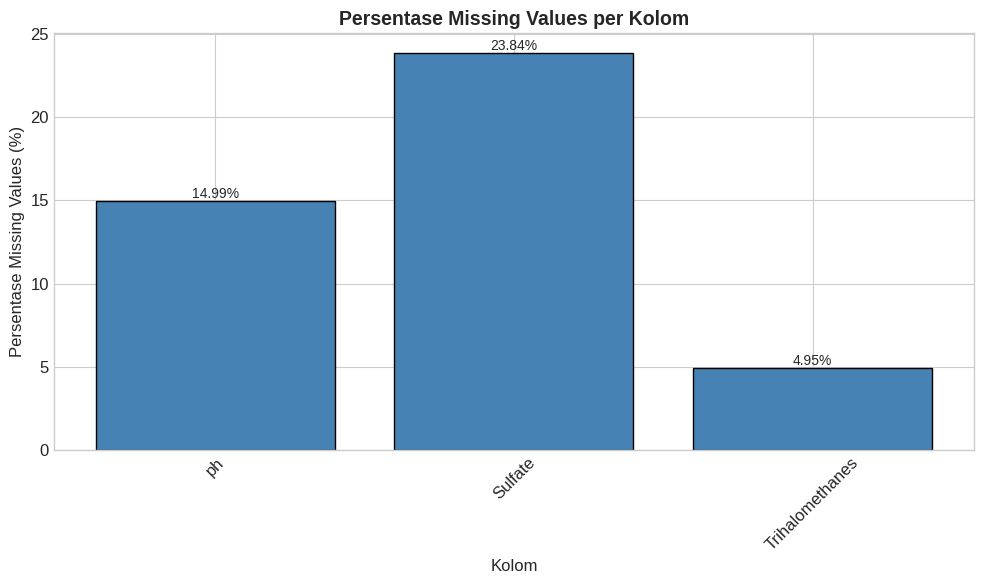

In [3]:
# Hitung missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Buat dataframe missing values
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Persentase (%)': missing_percentage.round(2)
})

print("=" * 60)
print("MISSING VALUES PER KOLOM")
print("=" * 60)
print(missing_df[missing_df['Missing Values'] > 0])

# Visualisasi missing values
plt.figure(figsize=(10, 6))
missing_to_plot = missing_df[missing_df['Missing Values'] > 0]
bars = plt.bar(missing_to_plot.index, missing_to_plot['Persentase (%)'], color='steelblue', edgecolor='black')
plt.xlabel('Kolom', fontsize=12)
plt.ylabel('Persentase Missing Values (%)', fontsize=12)
plt.title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 1.3 Statistik Deskriptif

In [4]:
print("=" * 80)
print("STATISTIK DESKRIPTIF SEMUA FITUR")
print("=" * 80)
print(df.describe().round(2))

STATISTIK DESKRIPTIF SEMUA FITUR
            ph  Hardness    Solids  Chloramines  Sulfate  Conductivity  \
count  2785.00   3276.00   3276.00      3276.00  2495.00       3276.00   
mean      7.08    196.37  22014.09         7.12   333.78        426.21   
std       1.59     32.88   8768.57         1.58    41.42         80.82   
min       0.00     47.43    320.94         0.35   129.00        181.48   
25%       6.09    176.85  15666.69         6.13   307.70        365.73   
50%       7.04    196.97  20927.83         7.13   333.07        421.88   
75%       8.06    216.67  27332.76         8.11   359.95        481.79   
max      14.00    323.12  61227.20        13.13   481.03        753.34   

       Organic_carbon  Trihalomethanes  Turbidity  Potability  
count         3276.00          3114.00    3276.00     3276.00  
mean            14.28            66.40       3.97        0.39  
std              3.31            16.18       0.78        0.49  
min              2.20             0.74      

### 1.4 Histogram Distribusi Tiap Fitur

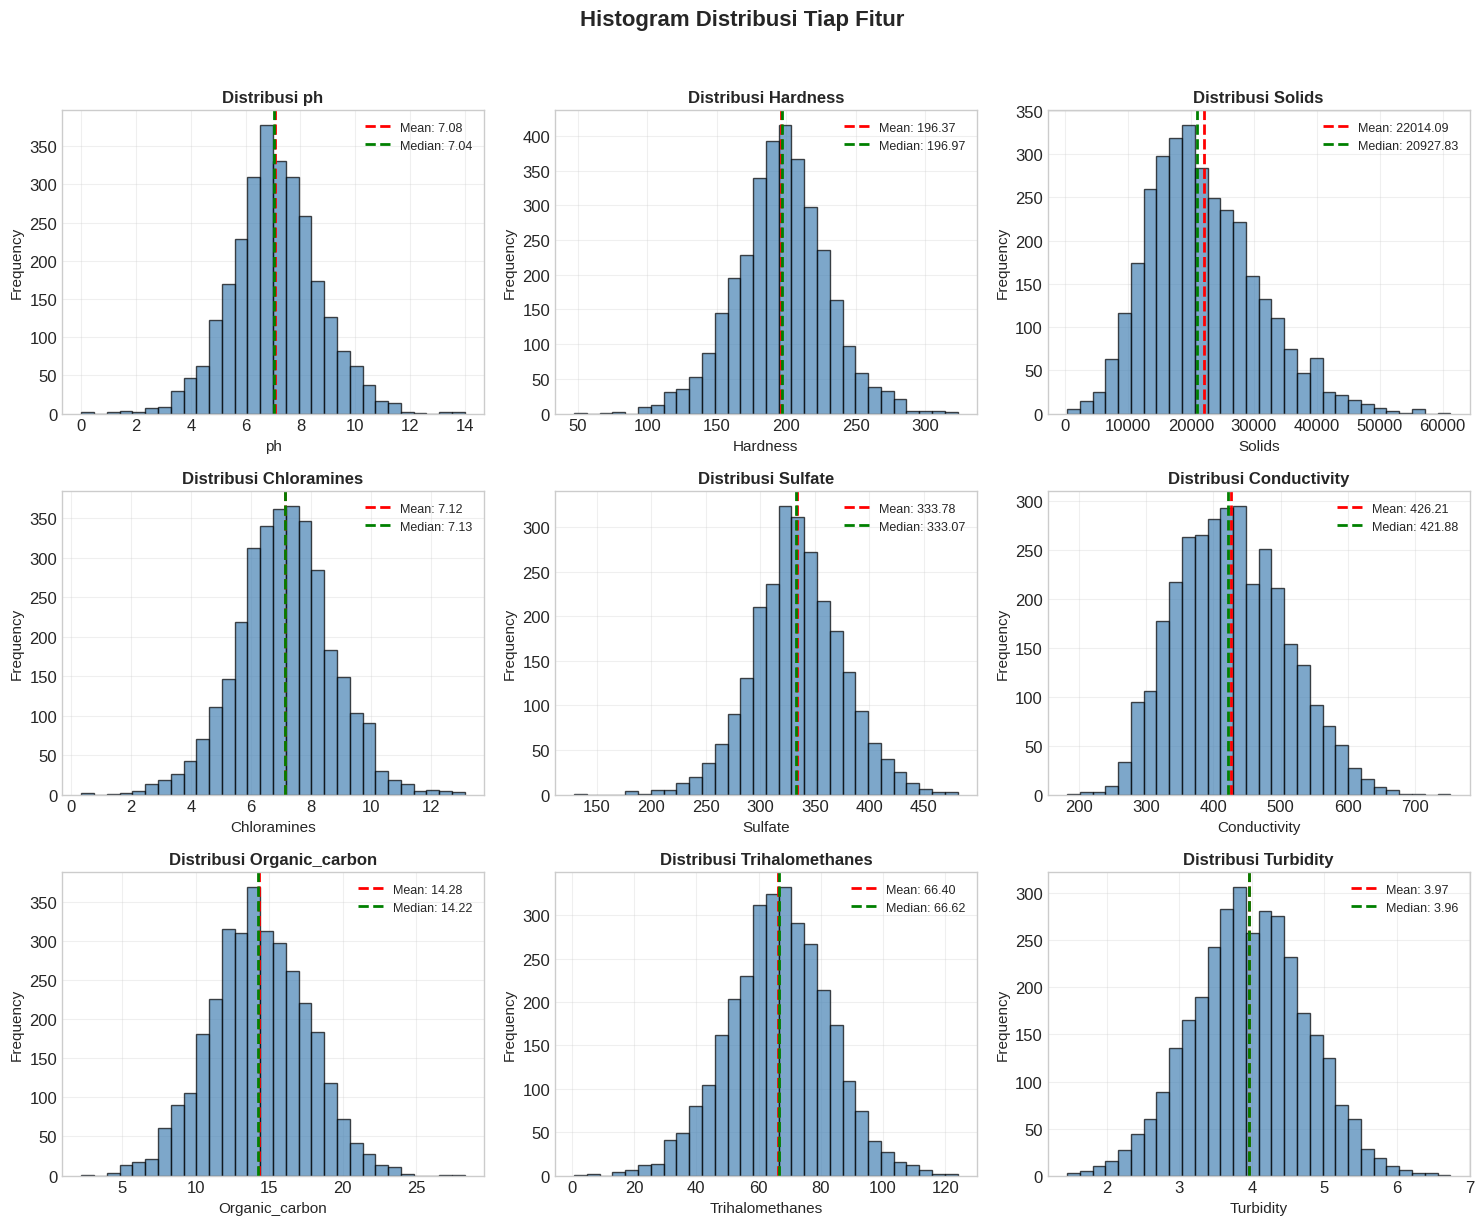

In [5]:
# Fitur-fitur (tidak termasuk Potability)
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

# Buat histogram 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[feature].mean():.2f}')
    axes[i].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[feature].median():.2f}')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Hide empty subplot if any
if len(features) < 9:
    axes[8].axis('off')

plt.suptitle('Histogram Distribusi Tiap Fitur', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Heatmap Korelasi Antar Fitur

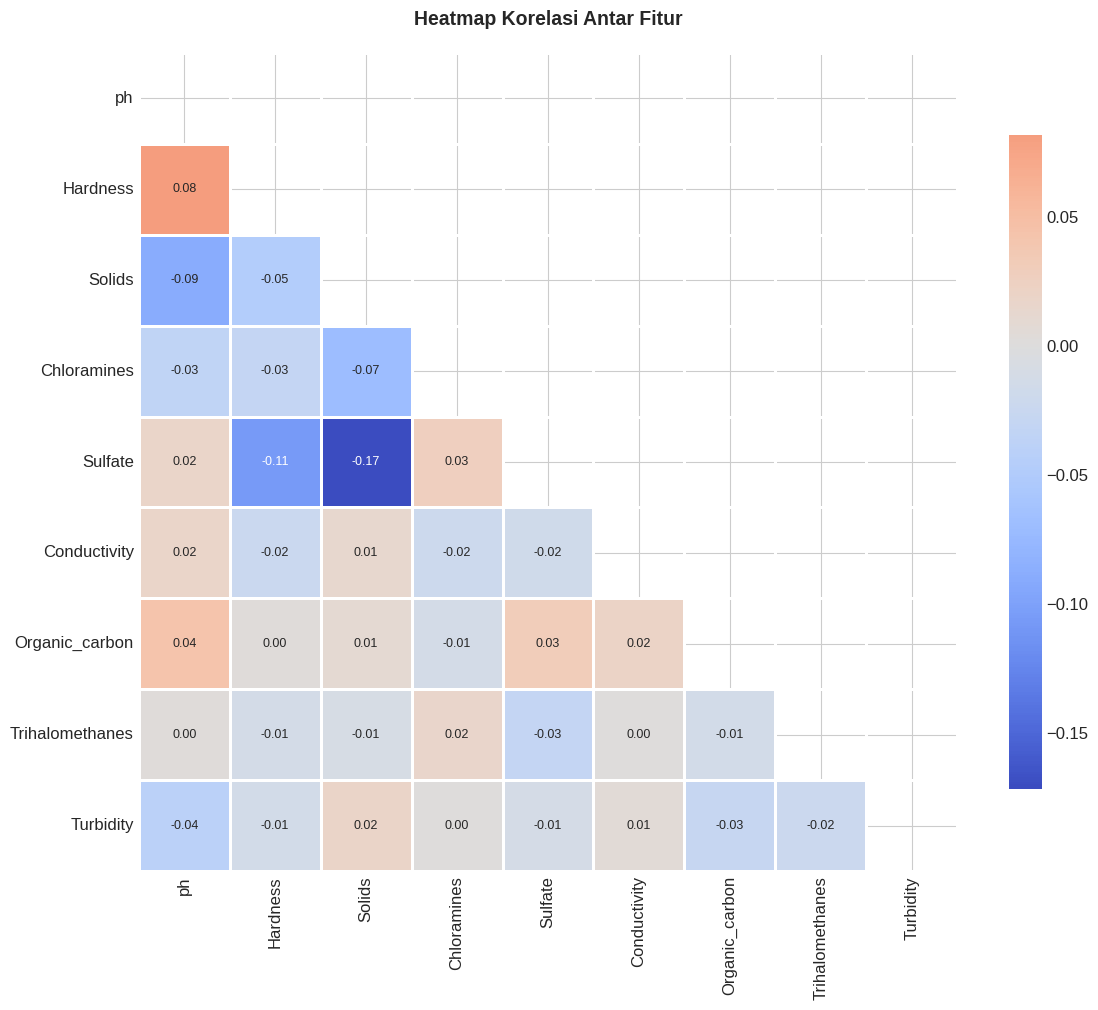


KORELASI TERTINGGI ANTAR FITUR


In [6]:
# Hitung korelasi (hapus Potability untuk saat ini)
corr_matrix = df[features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Tampilkan korelasi tertinggi (selain diagonal)
print("\n" + "=" * 60)
print("KORELASI TERTINGGI ANTAR FITUR")
print("=" * 60)

# Get upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))

# Find features with correlation > 0.3 or < -0.3
high_corr = []
for col in upper.columns:
    for idx in upper.index:
        if abs(upper.loc[idx, col]) > 0.3 and not np.isnan(upper.loc[idx, col]):
            high_corr.append((idx, col, upper.loc[idx, col]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

for feat1, feat2, corr in high_corr[:10]:
    print(f"{feat1:15} - {feat2:15}: {corr:.3f}")

---
## LANGKAH 2: PREPROCESSING

### 2.1 Hapus Kolom Potability

In [7]:
# Hapus kolom Potability sebelum proses clustering
df_clean = df.drop('Potability', axis=1)

print("Kolom setelah menghapus 'Potability':")
print(df_clean.columns.tolist())
print(f"\nShape dataset: {df_clean.shape}")

Kolom setelah menghapus 'Potability':
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Shape dataset: (3276, 9)


### 2.2 Imputasi Missing Values dengan Median

In [8]:
# SimpleImputer dengan median
imputer = SimpleImputer(strategy='median')

# Fit dan transform
df_imputed_array = imputer.fit_transform(df_clean)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_clean.columns)

# Verifikasi tidak ada missing values
print("=" * 60)
print("VERIFIKASI MISSING VALUES SETELAH IMPUTASI")
print("=" * 60)
print(f"Total missing values setelah imputasi: {df_imputed.isnull().sum().sum()}")
print("\nMissing values per kolom:")
print(df_imputed.isnull().sum())

VERIFIKASI MISSING VALUES SETELAH IMPUTASI
Total missing values setelah imputasi: 0

Missing values per kolom:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


### 2.3 Standarisasi dengan StandardScaler

In [9]:
# StandardScaler
scaler = StandardScaler()

# Fit dan transform
df_scaled_array = scaler.fit_transform(df_imputed)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_clean.columns)

# Verifikasi standarisasi
print("=" * 60)
print("STATISTIK SETELAH STANDARISASI")
print("=" * 60)
print("\nMean per fitur (harus mendekati 0):")
print(df_scaled.mean().round(10))
print("\nStd per fitur (harus mendekati 1):")
print(df_scaled.std().round(10))

STATISTIK SETELAH STANDARISASI

Mean per fitur (harus mendekati 0):
ph                 0.0
Hardness           0.0
Solids            -0.0
Chloramines        0.0
Sulfate           -0.0
Conductivity       0.0
Organic_carbon     0.0
Trihalomethanes   -0.0
Turbidity          0.0
dtype: float64

Std per fitur (harus mendekati 1):
ph                 1.000153
Hardness           1.000153
Solids             1.000153
Chloramines        1.000153
Sulfate            1.000153
Conductivity       1.000153
Organic_carbon     1.000153
Trihalomethanes    1.000153
Turbidity          1.000153
dtype: float64


---
## LANGKAH 3: MENENTUKAN JUMLAH CLUSTER OPTIMAL

### 3.1 K-Means untuk k=2 sampai k=8

In [10]:
# Range k yang akan diuji
k_range = range(2, 9)

# List untuk menyimpan inertia dan silhouette score
inertias = []
silhouette_scores = []

# Jalankan K-Means untuk setiap k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Buat tabel hasil
results_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

print("=" * 70)
print("TABEL HASIL K-MEANS UNTUK BERBAGAI NILAI K")
print("=" * 70)
print(results_df.to_string(index=False))

# Highlight k optimal berdasarkan silhouette score tertinggi
optimal_k_idx = results_df['Silhouette Score'].idxmax()
optimal_k = results_df.loc[optimal_k_idx, 'k']
print(f"\n{'=' * 70}")
print(f"K OPTIMAL BERDASARKAN SILHOUETTE SCORE TERTINGGI: k = {int(optimal_k)}")
print(f"Silhouette Score: {results_df.loc[optimal_k_idx, 'Silhouette Score']:.4f}")
print(f"{'=' * 70}")

TABEL HASIL K-MEANS UNTUK BERBAGAI NILAI K
 k      Inertia  Silhouette Score
 2 27089.648469          0.081876
 3 25359.747476          0.076591
 4 24150.127098          0.072795
 5 23116.580466          0.073704
 6 22273.547076          0.074474
 7 21543.720987          0.073277
 8 20892.466117          0.075405

K OPTIMAL BERDASARKAN SILHOUETTE SCORE TERTINGGI: k = 2
Silhouette Score: 0.0819


### 3.2 Elbow Method Plot

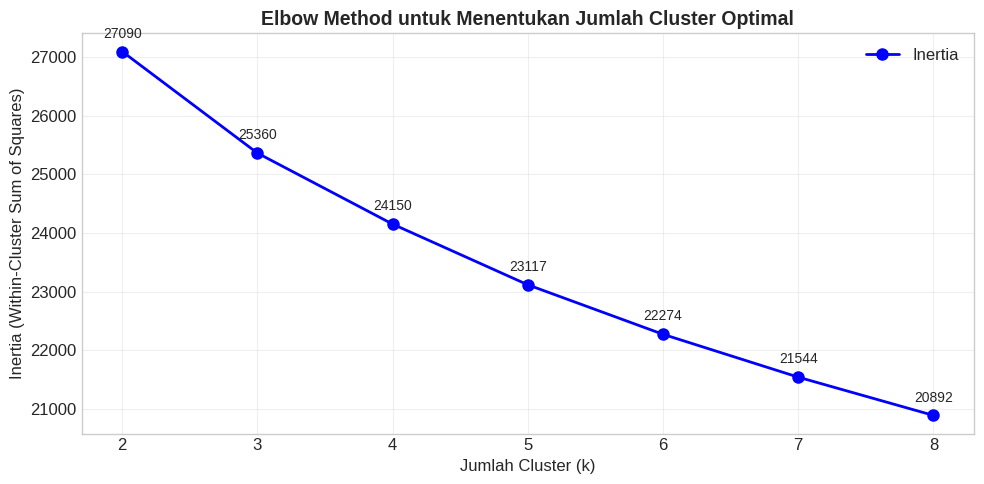

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, label='Inertia')
plt.xlabel('Jumlah Cluster (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Annotate points
for i, k in enumerate(k_range):
    plt.annotate(f'{inertias[i]:.0f}', (k, inertias[i]), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Silhouette Score Plot

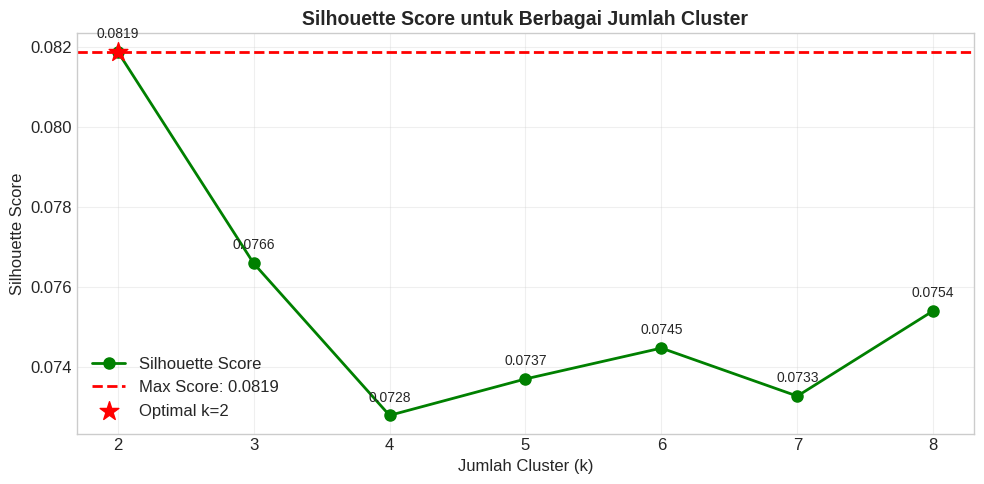

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8, label='Silhouette Score')
plt.xlabel('Jumlah Cluster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score untuk Berbagai Jumlah Cluster', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.axhline(y=max(silhouette_scores), color='r', linestyle='--', linewidth=2, 
            label=f'Max Score: {max(silhouette_scores):.4f}')

# Annotate points
for i, k in enumerate(k_range):
    plt.annotate(f'{silhouette_scores[i]:.4f}', (k, silhouette_scores[i]), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10)

# Highlight optimal k
plt.scatter([optimal_k], [max(silhouette_scores)], s=200, c='red', marker='*', 
            label=f'Optimal k={int(optimal_k)}', zorder=5)

plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Penjelasan Pemilihan K Optimal

In [13]:
print("=" * 80)
print("PENJELASAN PEMILIHAN K OPTIMAL")
print("=" * 80)
print(f"""
Berdasarkan hasil analisis di atas, K OPTIMAL yang dipilih adalah: K = {int(optimal_k)}

ALASAN PEMILIHAN:

1. SILHOUETTE SCORE TERTINGGI:
   - Nilai silhouette score untuk k={int(optimal_k)} adalah {max(silhouette_scores):.4f}
   - Ini adalah nilai tertinggi dibandingkan k lainnya
   - Silhouette score mengukur seberapa baik objek cocok dengan clusternya sendiri
     dibandingkan dengan cluster lain (range: -1 hingga 1)
   - Score {max(silhouette_scores):.4f} menunjukkan {'struktur cluster yang cukup baik' if max(silhouette_scores) > 0.2 else 'struktur cluster yang lemah'}

2. ELBOW METHOD:
   - Dari plot elbow, terlihat bahwa penurunan inertia mulai melambat setelah k={int(optimal_k)}
   - Inertia menurun dari {inertias[0]:.0f} (k=2) menjadi {inertias[-1]:.0f} (k=8)
   - Titik elbow menunjukkan trade-off yang baik antara kompakitas cluster dan jumlah cluster

3. INTERPRETABILITAS:
   - Jumlah {int(optimal_k)} cluster memberikan keseimbangan yang baik antara
     detail informasi dan kemudahan interpretasi
   - Tidak terlalu sedikit sehingga kehilangan informasi penting
   - Tidak terlalu banyak sehingga sulit diinterpretasi
""")

PENJELASAN PEMILIHAN K OPTIMAL

Berdasarkan hasil analisis di atas, K OPTIMAL yang dipilih adalah: K = 2

ALASAN PEMILIHAN:

1. SILHOUETTE SCORE TERTINGGI:
   - Nilai silhouette score untuk k=2 adalah 0.0819
   - Ini adalah nilai tertinggi dibandingkan k lainnya
   - Silhouette score mengukur seberapa baik objek cocok dengan clusternya sendiri
     dibandingkan dengan cluster lain (range: -1 hingga 1)
   - Score 0.0819 menunjukkan struktur cluster yang lemah

2. ELBOW METHOD:
   - Dari plot elbow, terlihat bahwa penurunan inertia mulai melambat setelah k=2
   - Inertia menurun dari 27090 (k=2) menjadi 20892 (k=8)
   - Titik elbow menunjukkan trade-off yang baik antara kompakitas cluster dan jumlah cluster

3. INTERPRETABILITAS:
   - Jumlah 2 cluster memberikan keseimbangan yang baik antara
     detail informasi dan kemudahan interpretasi
   - Tidak terlalu sedikit sehingga kehilangan informasi penting
   - Tidak terlalu banyak sehingga sulit diinterpretasi



---
## LANGKAH 4: CLUSTERING

### 4.1 K-Means Final dengan K Optimal

In [14]:
# K-Means final dengan k optimal
kmeans_final = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Tambahkan kolom Cluster ke dataframe
df_result = df_imputed.copy()  # Gunakan data yang sudah diimputasi (belum discale)
df_result['Cluster'] = cluster_labels

# Simpan juga data scaled dengan cluster label untuk analisis
df_scaled_result = df_scaled.copy()
df_scaled_result['Cluster'] = cluster_labels

print("=" * 60)
print("HASIL CLUSTERING K-MEANS FINAL")
print("=" * 60)
print(f"\nJumlah cluster: {int(optimal_k)}")
print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(df_scaled, cluster_labels):.4f}")
print(f"Jumlah iterasi: {kmeans_final.n_iter_}")

HASIL CLUSTERING K-MEANS FINAL

Jumlah cluster: 2
Inertia: 27089.65
Silhouette Score: 0.0819
Jumlah iterasi: 32


### 4.2 Jumlah Sampel dan Persentase Tiap Cluster

DISTRIBUSI SAMPEL PER CLUSTER
         Jumlah Sampel  Persentase (%)
Cluster                               
0                 1431           43.68
1                 1845           56.32

Total: 3276 sampel


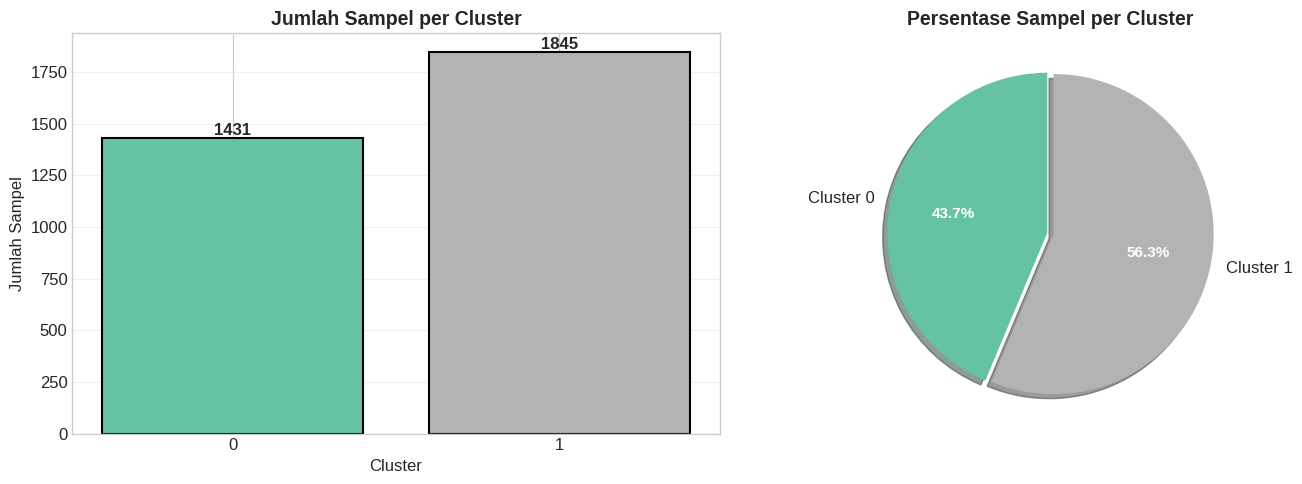

In [15]:
# Hitung jumlah dan persentase per cluster
cluster_counts = df_result['Cluster'].value_counts().sort_index()
cluster_percentages = (cluster_counts / len(df_result) * 100).round(2)

cluster_summary = pd.DataFrame({
    'Jumlah Sampel': cluster_counts,
    'Persentase (%)': cluster_percentages
})

print("=" * 60)
print("DISTRIBUSI SAMPEL PER CLUSTER")
print("=" * 60)
print(cluster_summary.to_string())
print(f"\nTotal: {len(df_result)} sampel")

# Visualisasi distribusi cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart jumlah sampel
colors = plt.cm.Set2(np.linspace(0, 1, int(optimal_k)))
bars1 = axes[0].bar(cluster_summary.index.astype(str), cluster_summary['Jumlah Sampel'], 
                    color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel', fontsize=12)
axes[0].set_title('Jumlah Sampel per Cluster', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart persentase
wedges, texts, autotexts = axes[1].pie(cluster_summary['Jumlah Sampel'], 
                                        labels=[f'Cluster {i}' for i in cluster_summary.index],
                                        autopct='%1.1f%%', colors=colors, 
                                        explode=[0.02]*int(optimal_k),
                                        shadow=True, startangle=90)
axes[1].set_title('Persentase Sampel per Cluster', fontsize=14, fontweight='bold')

# Style pie chart text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

---
## LANGKAH 5: VISUALISASI

### 5.1 Scatter Plot PCA 2D

HASIL PCA
Variance yang dijelaskan PC1: 0.1334 (13.34%)
Variance yang dijelaskan PC2: 0.1263 (12.63%)
Total variance yang dijelaskan: 0.2597 (25.97%)


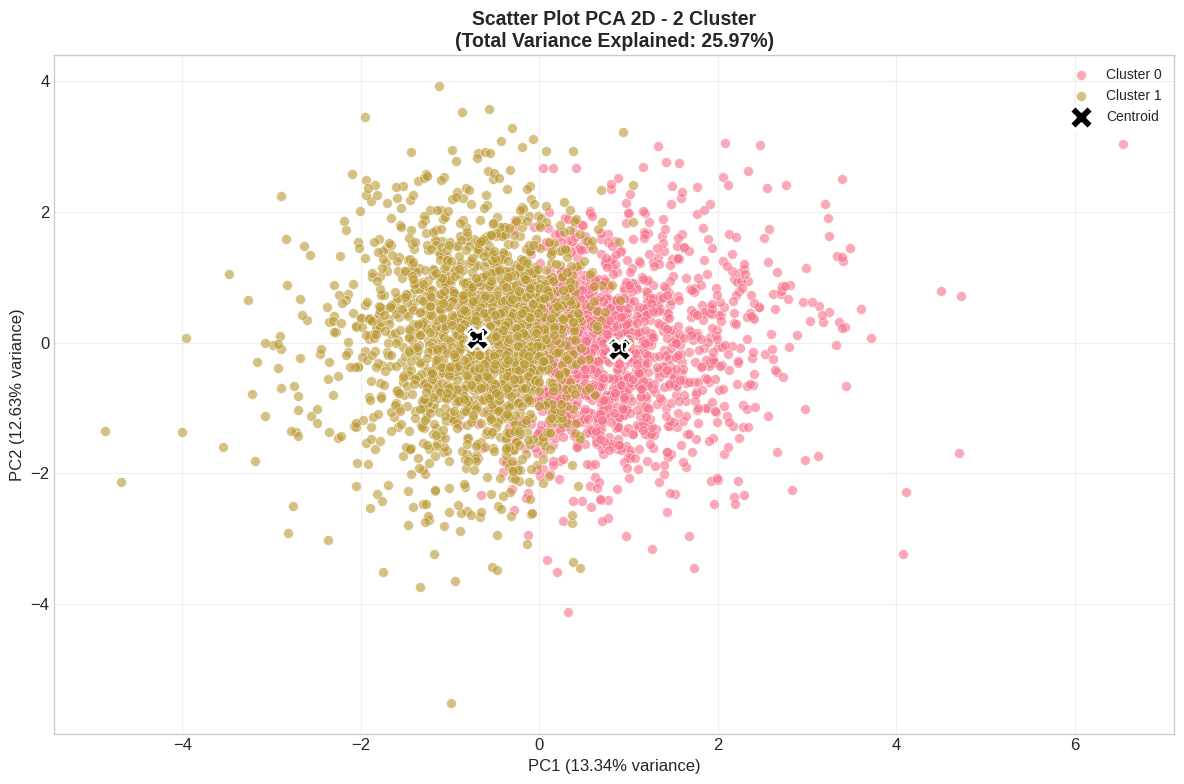

In [16]:
# PCA untuk reduksi dimensi ke 2D
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

# Variance yang dijelaskan
explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum()

print("=" * 60)
print("HASIL PCA")
print("=" * 60)
print(f"Variance yang dijelaskan PC1: {explained_variance[0]:.4f} ({explained_variance[0]*100:.2f}%)")
print(f"Variance yang dijelaskan PC2: {explained_variance[1]:.4f} ({explained_variance[1]*100:.2f}%)")
print(f"Total variance yang dijelaskan: {total_variance:.4f} ({total_variance*100:.2f}%)")

# Centroid dalam ruang PCA
centroid_pca = pca.transform(kmeans_final.cluster_centers_)

# Scatter plot
plt.figure(figsize=(12, 8))

# Plot setiap cluster dengan warna berbeda
for cluster in range(int(optimal_k)):
    mask = df_result['Cluster'] == cluster
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], 
                alpha=0.6, s=50, label=f'Cluster {cluster}',
                edgecolors='w', linewidth=0.5)

# Plot centroid dengan marker X hitam
plt.scatter(centroid_pca[:, 0], centroid_pca[:, 1], 
            marker='X', s=300, c='black', edgecolors='white', 
            linewidths=2, label='Centroid', zorder=10)

# Add centroid labels
for i, (x, y) in enumerate(centroid_pca):
    plt.annotate(f'C{i}', (x, y), fontsize=12, fontweight='bold', 
                 ha='center', va='center', color='white', zorder=11)

plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% variance)', fontsize=12)
plt.title(f'Scatter Plot PCA 2D - {int(optimal_k)} Cluster\n(Total Variance Explained: {total_variance*100:.2f}%)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Bar Chart Perbandingan Rata-rata Tiap Fitur per Cluster

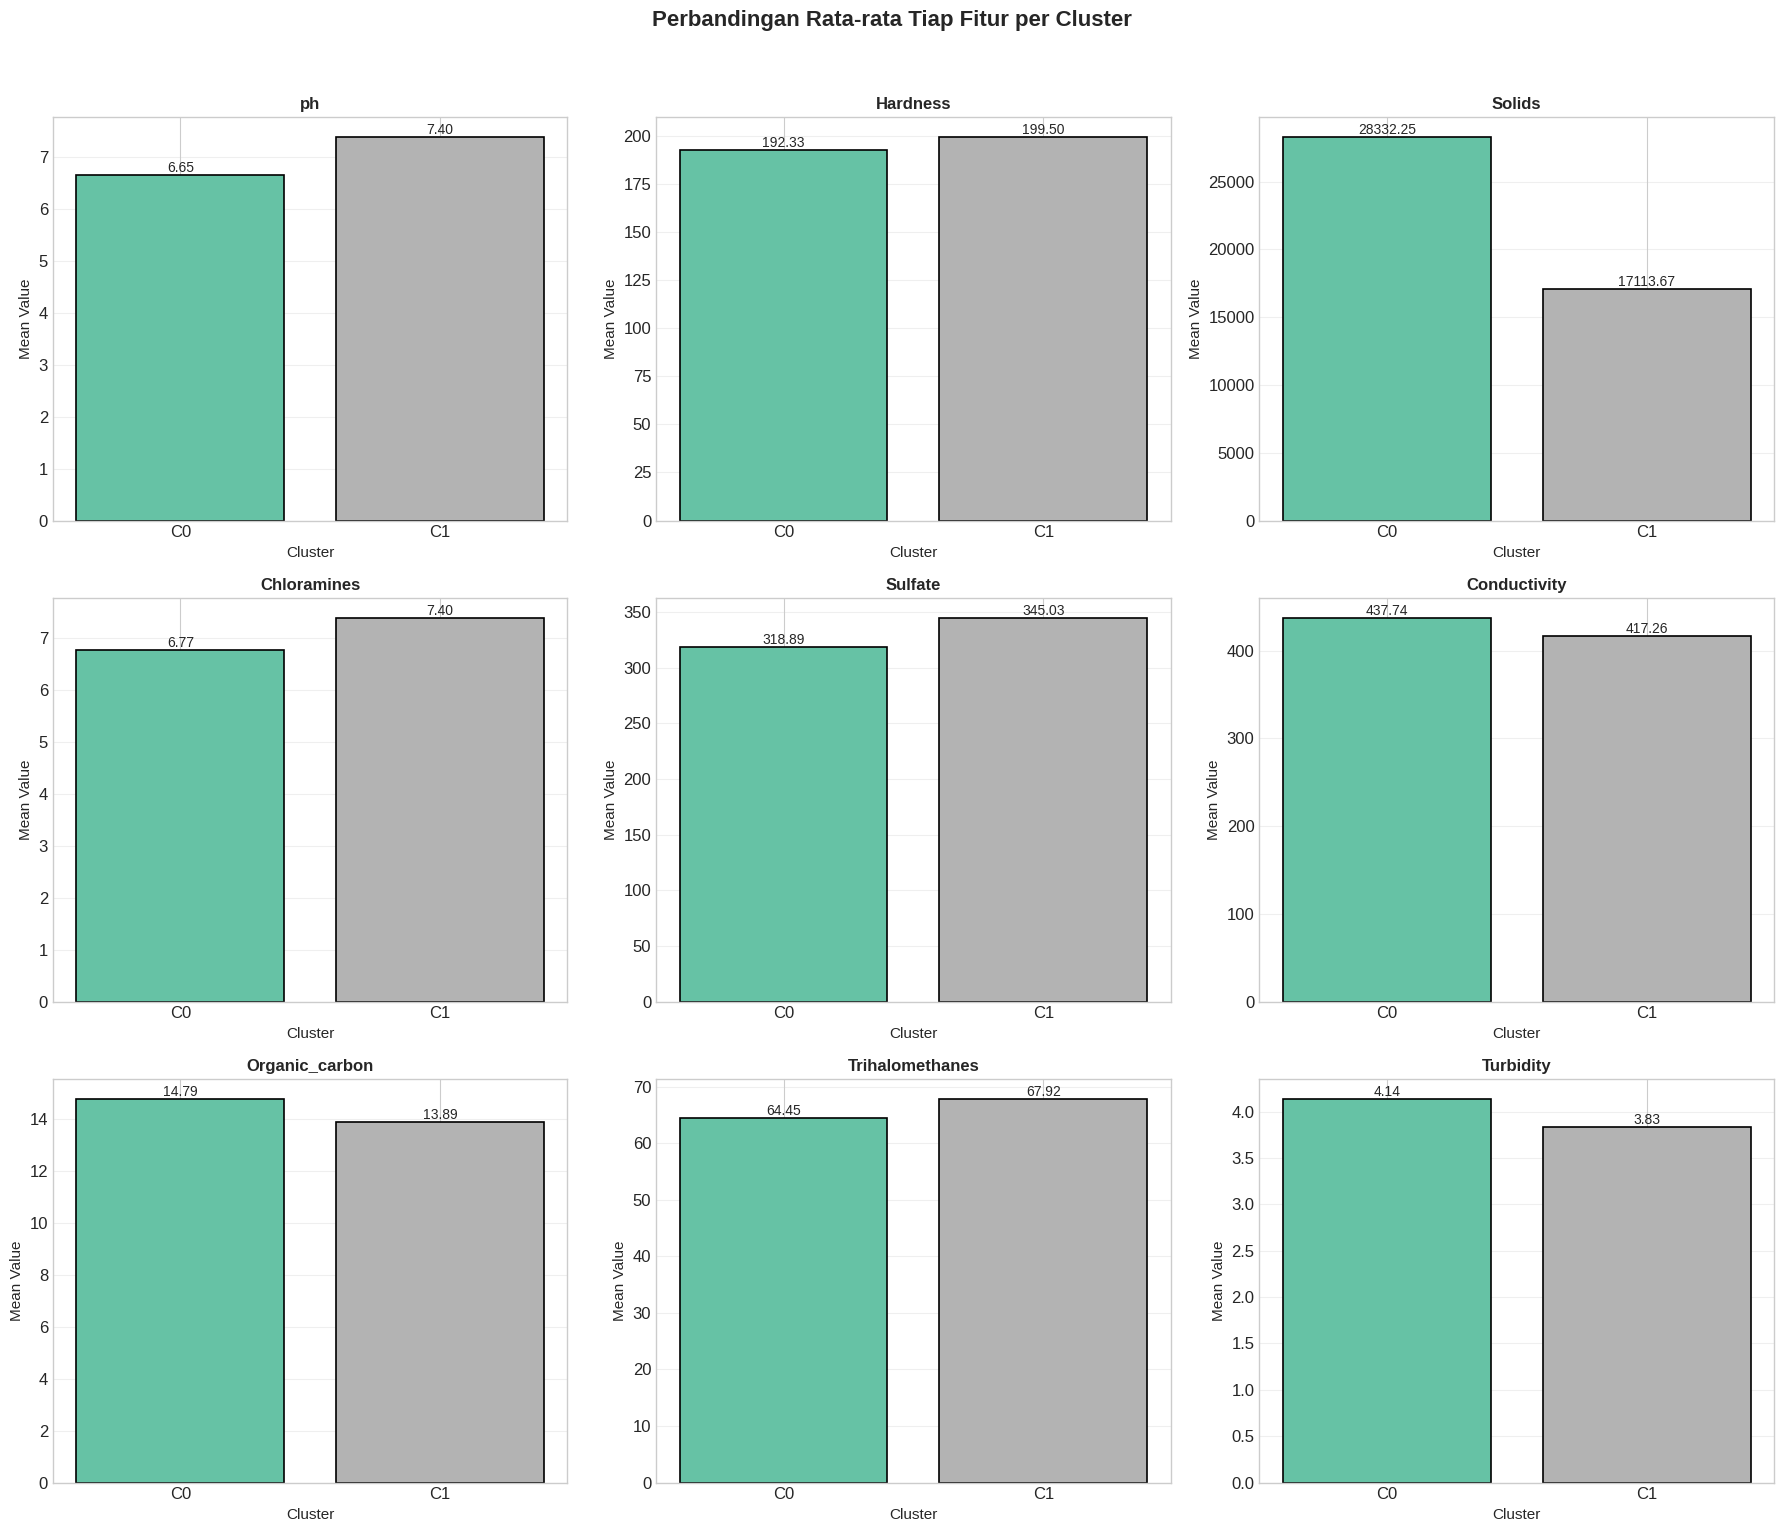

In [17]:
# Hitung mean per fitur per cluster
cluster_means = df_result.groupby('Cluster')[features].mean()

# Buat 3x3 grid bar charts
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, int(optimal_k)))

for i, feature in enumerate(features):
    means = cluster_means[feature].values
    x_pos = range(int(optimal_k))
    
    bars = axes[i].bar(x_pos, means, color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=10)
    
    axes[i].set_xlabel('Cluster', fontsize=11)
    axes[i].set_ylabel('Mean Value', fontsize=11)
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels([f'C{i}' for i in range(int(optimal_k))])
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Perbandingan Rata-rata Tiap Fitur per Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Boxplot Distribusi Tiap Fitur per Cluster

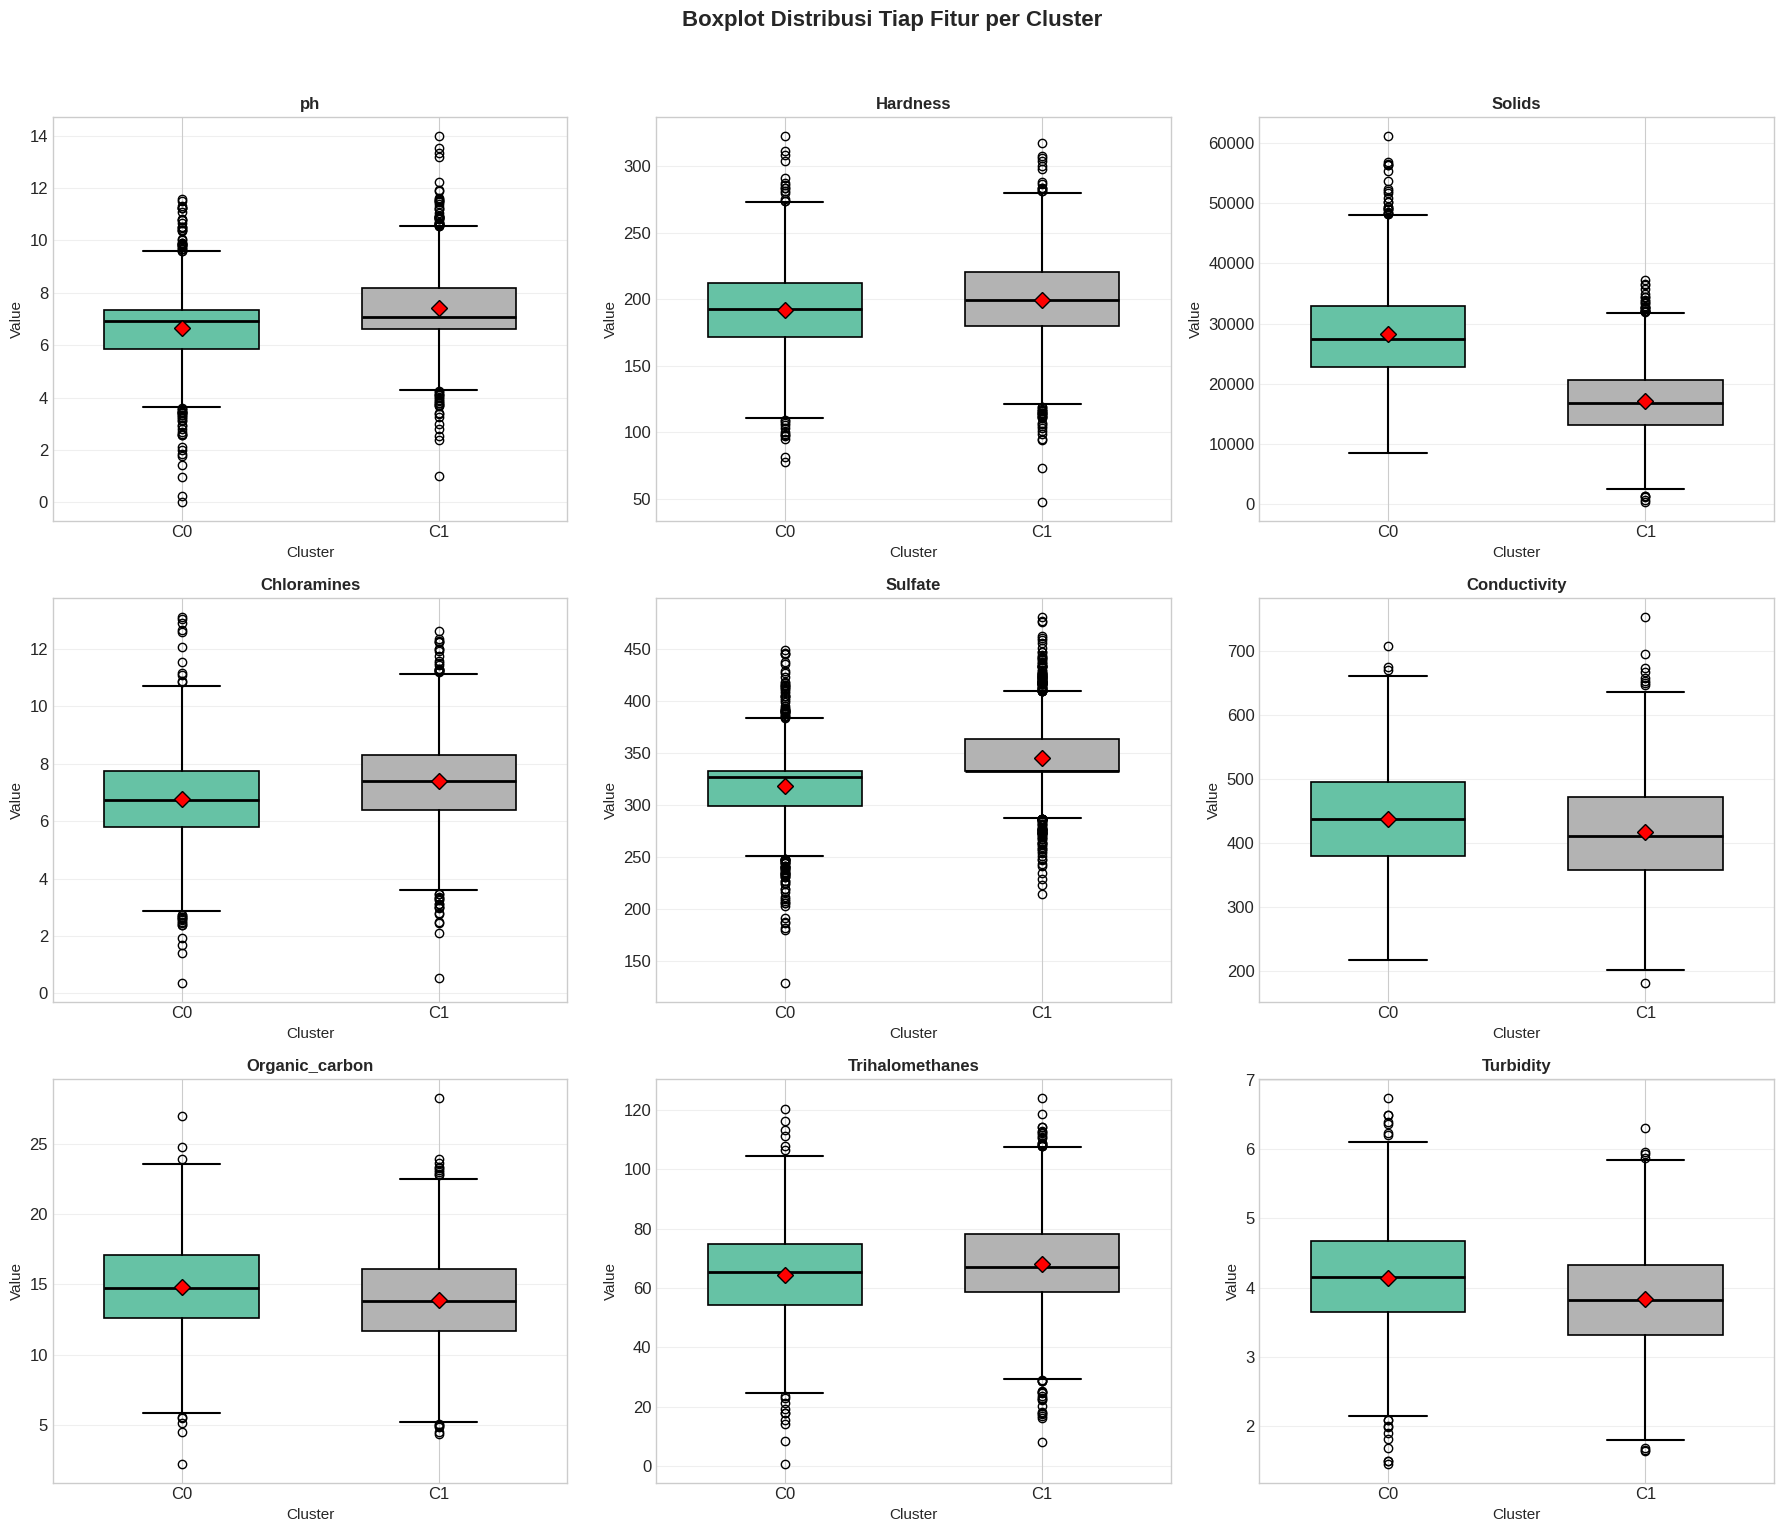

In [18]:
# Buat 3x3 grid boxplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, int(optimal_k)))

for i, feature in enumerate(features):
    # Prepare data for boxplot
    data_to_plot = []
    labels = []
    for cluster in range(int(optimal_k)):
        data_to_plot.append(df_result[df_result['Cluster'] == cluster][feature].values)
        labels.append(f'C{cluster}')
    
    # Create boxplot
    bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True, 
                         widths=0.6, showmeans=True,
                         meanprops=dict(marker='D', markerfacecolor='red', 
                                       markeredgecolor='black', markersize=8))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    # Style whiskers and caps
    for whisker in bp['whiskers']:
        whisker.set_color('black')
        whisker.set_linewidth(1.5)
    for cap in bp['caps']:
        cap.set_color('black')
        cap.set_linewidth(1.5)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    axes[i].set_xlabel('Cluster', fontsize=11)
    axes[i].set_ylabel('Value', fontsize=11)
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplot Distribusi Tiap Fitur per Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Radar Chart untuk Membandingkan Profil Tiap Cluster

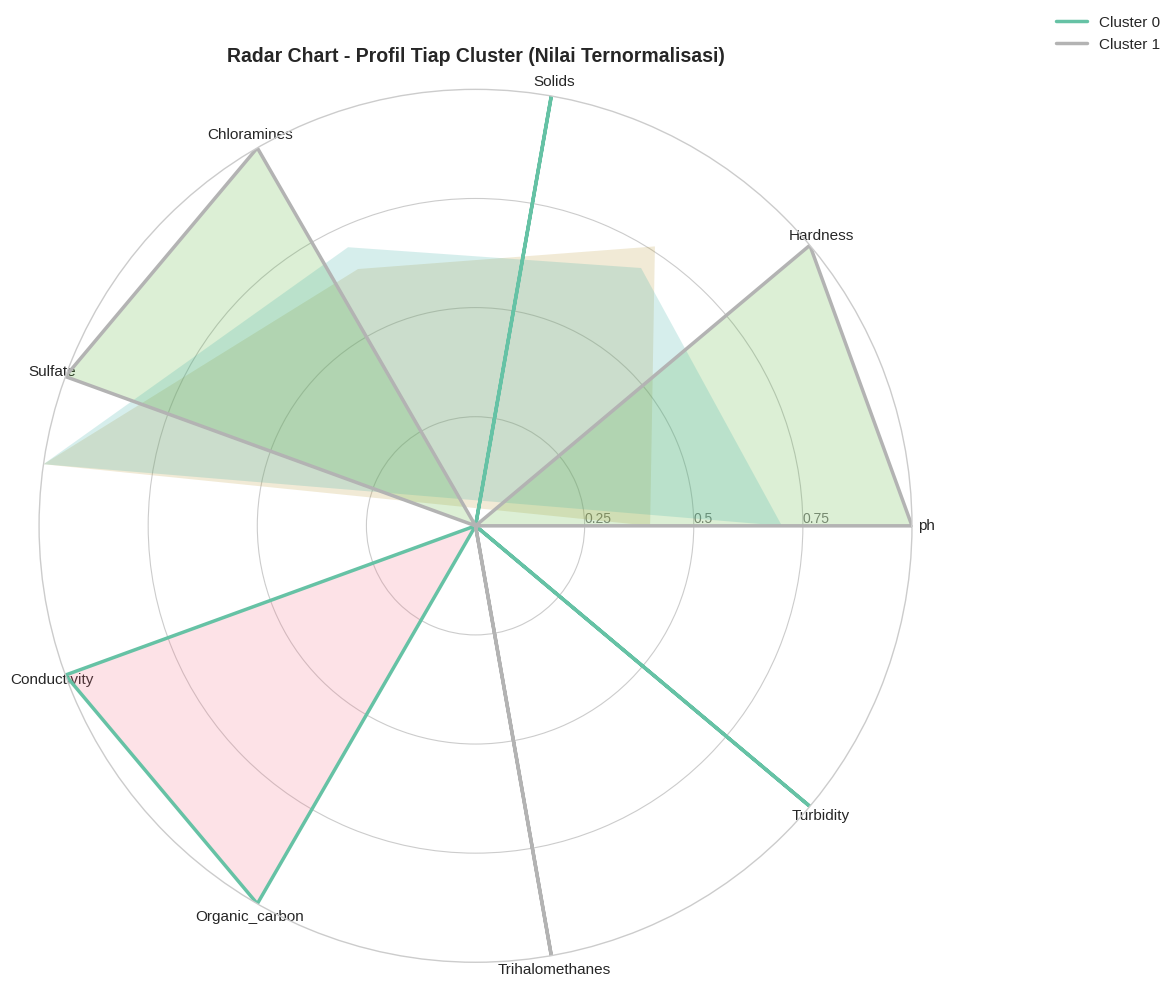

In [19]:
from math import pi

# Normalisasi data untuk radar chart (min-max scaling per fitur)
cluster_means_scaled = cluster_means.copy()
for feature in features:
    min_val = cluster_means[feature].min()
    max_val = cluster_means[feature].max()
    if max_val - min_val > 0:
        cluster_means_scaled[feature] = (cluster_means[feature] - min_val) / (max_val - min_val)
    else:
        cluster_means_scaled[feature] = 0.5

# Buat radar chart
fig = plt.figure(figsize=(12, 12))

# Calculate angles
angles = [n / float(len(features)) * 2 * pi for n in range(len(features))]
angles += angles[:1]  # Close the loop

# Create subplot
ax = fig.add_subplot(111, polar=True)

# Draw one axe per variable and add labels
plt.xticks(angles[:-1], features, fontsize=11)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=10)
plt.ylim(0, 1)

# Plot data for each cluster
for cluster in range(int(optimal_k)):
    values = cluster_means_scaled.loc[cluster].values.flatten().tolist()
    values += values[:1]  # Close the loop
    
    ax.plot(angles, values, linewidth=2.5, label=f'Cluster {cluster}', color=colors[cluster])
    ax.fill(angles, values, colors[cluster], alpha=0.2)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('Radar Chart - Profil Tiap Cluster (Nilai Ternormalisasi)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 5.5 Bar Chart Horizontal Fitur Pembeda Terbesar

FITUR PEMBEDA TERBESAR (DIURUTKAN DARI SELISIH TERBESAR)
        Feature  Max Difference
         Solids    11218.577858
        Sulfate       26.141822
   Conductivity       20.479049
       Hardness        7.176651
Trihalomethanes        3.468628
 Organic_carbon        0.900279
             ph        0.746992
    Chloramines        0.630905
      Turbidity        0.310906


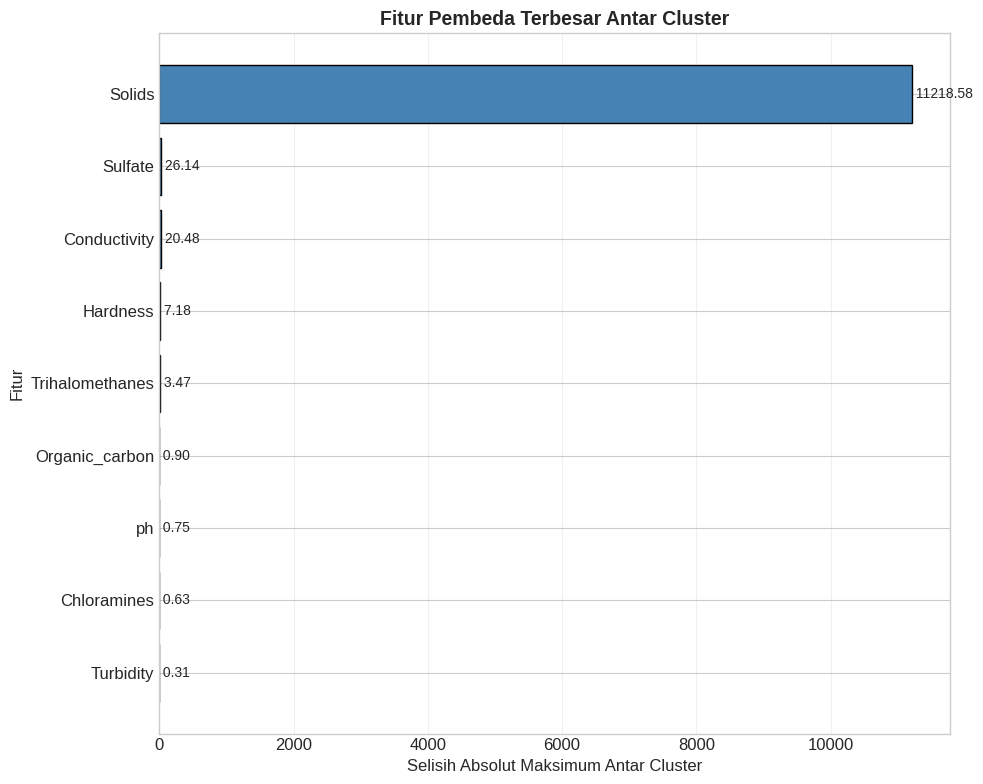

In [20]:
# Hitung selisih absolut terbesar antar cluster untuk tiap fitur
feature_diff = []
for feature in features:
    max_val = cluster_means[feature].max()
    min_val = cluster_means[feature].min()
    diff = max_val - min_val
    feature_diff.append((feature, diff))

# Urutkan dari selisih terbesar
feature_diff.sort(key=lambda x: x[1], reverse=True)

# Buat dataframe
diff_df = pd.DataFrame(feature_diff, columns=['Feature', 'Max Difference'])

print("=" * 60)
print("FITUR PEMBEDA TERBESAR (DIURUTKAN DARI SELISIH TERBESAR)")
print("=" * 60)
print(diff_df.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 8))

y_pos = range(len(diff_df))
bars = plt.barh(y_pos, diff_df['Max Difference'], color='steelblue', edgecolor='black')
plt.yticks(y_pos, diff_df['Feature'])
plt.xlabel('Selisih Absolut Maksimum Antar Cluster', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.title('Fitur Pembeda Terbesar Antar Cluster', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest difference at top
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, i, f' {width:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## LANGKAH 6: INTERPRETASI DAN INSIGHT

### 6.1 Tabel Perbandingan Rata-rata Tiap Fitur per Cluster

In [21]:
print("=" * 100)
print("TABEL PERBANDINGAN RATA-RATA TIAP FITUR PER CLUSTER")
print("=" * 100)
print("\nNilai rata-rata (mean) setiap fitur untuk setiap cluster:")
print("\n" + cluster_means.round(2).to_string())

# Tambahkan statistik
print("\n" + "=" * 100)
print("STATISTIK LENGKAP PER CLUSTER")
print("=" * 100)

cluster_stats = df_result.groupby('Cluster')[features].agg(['mean', 'std', 'min', 'max'])
print(cluster_stats.round(2).to_string())

TABEL PERBANDINGAN RATA-RATA TIAP FITUR PER CLUSTER

Nilai rata-rata (mean) setiap fitur untuk setiap cluster:

           ph  Hardness    Solids  Chloramines  Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity
Cluster                                                                                                          
0        6.65    192.33  28332.25         6.77   318.89        437.74           14.79            64.45       4.14
1        7.40    199.50  17113.67         7.40   345.03        417.26           13.89            67.92       3.83

STATISTIK LENGKAP PER CLUSTER
           ph                    Hardness                          Solids                             Chloramines                    Sulfate                        Conductivity                        Organic_carbon                    Trihalomethanes                      Turbidity                  
         mean   std   min    max     mean    std    min     max      mean      std      min       max 

### 6.2 Tabel Selisih Absolut dan Persentase Antar Cluster

In [22]:
# Hitung selisih absolut dan persentase
diff_analysis = []
for feature in features:
    max_val = cluster_means[feature].max()
    min_val = cluster_means[feature].min()
    abs_diff = max_val - min_val
    # Persentase perbedaan relatif terhadap nilai minimum
    if min_val > 0:
        pct_diff = ((max_val - min_val) / min_val) * 100
    else:
        pct_diff = ((max_val - min_val) / (max_val + 0.001)) * 100
    
    # Cluster dengan nilai tertinggi dan terendah
    max_cluster = cluster_means[feature].idxmax()
    min_cluster = cluster_means[feature].idxmin()
    
    diff_analysis.append({
        'Feature': feature,
        'Abs Difference': abs_diff,
        'Pct Difference (%)': pct_diff,
        'Max Cluster': max_cluster,
        'Min Cluster': min_cluster,
        'Max Value': max_val,
        'Min Value': min_val
    })

diff_df_detailed = pd.DataFrame(diff_analysis)
diff_df_detailed = diff_df_detailed.sort_values('Abs Difference', ascending=False)

print("=" * 120)
print("TABEL SELISIH ABSOLUT DAN PERSENTASE ANTAR CLUSTER")
print("=" * 120)
print(diff_df_detailed[['Feature', 'Abs Difference', 'Pct Difference (%)', 'Max Cluster', 'Min Cluster']].to_string(index=False))

TABEL SELISIH ABSOLUT DAN PERSENTASE ANTAR CLUSTER
        Feature  Abs Difference  Pct Difference (%)  Max Cluster  Min Cluster
         Solids    11218.577858           65.553315            0            1
        Sulfate       26.141822            8.197868            1            0
   Conductivity       20.479049            4.907987            0            1
       Hardness        7.176651            3.731470            1            0
Trihalomethanes        3.468628            5.381556            1            0
 Organic_carbon        0.900279            6.480691            0            1
             ph        0.746992           11.227054            1            0
    Chloramines        0.630905            9.323312            1            0
      Turbidity        0.310906            8.115585            0            1


### 6.3 Narasi Interpretasi

In [23]:
print("=" * 80)
print("NARASI INTERPRETASI HASIL CLUSTERING")
print("=" * 80)

sil_score = silhouette_score(df_scaled, cluster_labels)

print(f"""
1. JUMLAH CLUSTER YANG TERBENTUK DAN ALASAN PEMILIHAN K
   --------------------------------------------------------
   Jumlah cluster yang terbentuk: {int(optimal_k)} cluster
   
   Alasan pemilihan k={int(optimal_k)}:
   - Berdasarkan Silhouette Score tertinggi: {max(silhouette_scores):.4f}
   - Elbow method menunjukkan titik optimal pada k={int(optimal_k)}
   - Jumlah ini memberikan keseimbangan antara detail informasi dan interpretabilitas

2. KARAKTERISTIK TIAP CLUSTER BERDASARKAN NILAI RATA-RATA FITUR
   ---------------------------------------------------------------
""")

# Analisis setiap cluster
for cluster in range(int(optimal_k)):
    print(f"\n   CLUSTER {cluster}:")
    print(f"   Jumlah sampel: {cluster_counts[cluster]} ({cluster_percentages[cluster]:.2f}%)")
    print("   Karakteristik fitur:")
    
    # Urutkan fitur berdasarkan nilai untuk cluster ini
    cluster_profile = cluster_means.loc[cluster].sort_values(ascending=False)
    
    for feature in features:
        val = cluster_means.loc[cluster, feature]
        overall_mean = df_result[feature].mean()
        status = "TINGGI" if val > overall_mean else "RENDAH"
        print(f"      - {feature}: {val:.2f} ({status} - rata-rata keseluruhan: {overall_mean:.2f})")

print(f"""
3. FITUR YANG PALING MEMBEDAKAN ANTAR CLUSTER
   ---------------------------------------------
   Berdasarkan analisis selisih absolut:
""")

for i, row in diff_df_detailed.head(5).iterrows():
    print(f"   - {row['Feature']}: selisih {row['Abs Difference']:.2f} ({row['Pct Difference (%)']:.1f}%)")
    print(f"     Cluster tertinggi: C{int(row['Max Cluster'])} ({row['Max Value']:.2f})")
    print(f"     Cluster terendah: C{int(row['Min Cluster'])} ({row['Min Value']:.2f})")

print(f"""
4. INTERPRETASI SILHOUETTE SCORE
   -------------------------------
   Silhouette Score yang dihasilkan: {sil_score:.4f}
""")

if sil_score > 0.5:
    interpretation = "STRUKTUR CLUSTER KUAT - Cluster terpisah dengan sangat baik"
elif sil_score > 0.25:
    interpretation = "STRUKTUR CLUSTER SEDANG - Cluster terpisah cukup baik, ada beberapa overlap"
else:
    interpretation = "STRUKTUR CLUSTER LEMAH - Cluster tidak terpisah dengan jelas, banyak overlap"

print(f"   Interpretasi: {interpretation}")
print(f"""
   Silhouette score mendekati 1 berarti objek sangat cocok dengan clusternya sendiri
   dan jauh dari cluster lain. Score {sil_score:.4f} menunjukkan bahwa:
   - {'Objek dalam cluster memiliki kemiripan yang baik' if sil_score > 0.25 else 'Ada overlap signifikan antar cluster'}
   - {'Cluster terpisah dengan cukup baik' if sil_score > 0.25 else 'Pemisahan cluster masih dapat ditingkatkan'}

5. INSIGHT PRAKTIS DALAM KONTEKS KUALITAS AIR
   --------------------------------------------
   Berdasarkan karakteristik fitur setiap cluster:
""")

# Insight per cluster
for cluster in range(int(optimal_k)):
    print(f"\n   Cluster {cluster}:")
    
    # Identifikasi fitur dengan nilai ekstrem untuk cluster ini
    cluster_vals = cluster_means.loc[cluster]
    overall_means = df_result[features].mean()
    
    high_features = cluster_vals[cluster_vals > overall_means * 1.1].index.tolist()
    low_features = cluster_vals[cluster_vals < overall_means * 0.9].index.tolist()
    
    if high_features:
        print(f"      Memiliki nilai TINGGI pada: {', '.join(high_features)}")
    if low_features:
        print(f"      Memiliki nilai RENDAH pada: {', '.join(low_features)}")
    
    # Interpretasi praktis
    ph_val = cluster_means.loc[cluster, 'ph']
    turbidity_val = cluster_means.loc[cluster, 'Turbidity']
    hardness_val = cluster_means.loc[cluster, 'Hardness']
    
    if ph_val < 6.5:
        print(f"      → Air cenderung ASAM (pH {ph_val:.2f}), perlu penanganan untuk menaikkan pH")
    elif ph_val > 8.5:
        print(f"      → Air cenderung BASA (pH {ph_val:.2f}), perlu penanganan untuk menurunkan pH")
    else:
        print(f"      → pH air dalam rentang normal (pH {ph_val:.2f})")
    
    if turbidity_val > 5:
        print(f"      → Kekeruhan tinggi ({turbidity_val:.2f}), perlu filtrasi")
    else:
        print(f"      → Kekeruhan rendah ({turbidity_val:.2f}), kualitas visual baik")

print("\n" + "=" * 80)

NARASI INTERPRETASI HASIL CLUSTERING

1. JUMLAH CLUSTER YANG TERBENTUK DAN ALASAN PEMILIHAN K
   --------------------------------------------------------
   Jumlah cluster yang terbentuk: 2 cluster

   Alasan pemilihan k=2:
   - Berdasarkan Silhouette Score tertinggi: 0.0819
   - Elbow method menunjukkan titik optimal pada k=2
   - Jumlah ini memberikan keseimbangan antara detail informasi dan interpretabilitas

2. KARAKTERISTIK TIAP CLUSTER BERDASARKAN NILAI RATA-RATA FITUR
   ---------------------------------------------------------------


   CLUSTER 0:
   Jumlah sampel: 1431 (43.68%)
   Karakteristik fitur:
      - ph: 6.65 (RENDAH - rata-rata keseluruhan: 7.07)
      - Hardness: 192.33 (RENDAH - rata-rata keseluruhan: 196.37)
      - Solids: 28332.25 (TINGGI - rata-rata keseluruhan: 22014.09)
      - Chloramines: 6.77 (RENDAH - rata-rata keseluruhan: 7.12)
      - Sulfate: 318.89 (RENDAH - rata-rata keseluruhan: 333.61)
      - Conductivity: 437.74 (TINGGI - rata-rata keseluruhan:

---
## LANGKAH 7: LAPORAN LENGKAP

In [24]:
laporan = """
================================================================================
                    LAPORAN ANALISIS CLUSTERING
                    DATASET WATER POTABILITY
================================================================================

1. PENDAHULUAN
--------------------------------------------------------------------------------
Latar Belakang:
Kualitas air merupakan faktor penting untuk kesehatan masyarakat. Dengan 
menganalisis karakteristik fisika-kimia air, kita dapat mengidentifikasi pola 
dan kelompok sampel air yang memiliki karakteristik serupa. Analisis clustering 
unsupervised memungkinkan kita untuk menemukan struktur alami dalam data tanpa 
menggunakan label yang sudah ada.

Tujuan Analisis:
- Mengidentifikasi kelompok-kelompok sampel air berdasarkan karakteristiknya
- Memahami pola distribusi fitur-fitur kualitas air
- Memberikan insight untuk klasifikasi dan penanganan kualitas air

2. DESKRIPSI DATASET
--------------------------------------------------------------------------------
File: water_potability.csv
Jumlah Sampel: 3.276 baris data
Jumlah Fitur: 9 fitur + 1 kolom target (Potability)

Fitur-fitur:
- ph: Tingkat keasaman air (range normal: 6.5-8.5)
- Hardness: Kekerasan air berdasarkan kandungan mineral (Ca, Mg)
- Solids: Total padatan terlarut dalam air (TDS)
- Chloramines: Senyawa disinfektan yang digunakan dalam pengolahan air
- Sulfate: Kandungan sulfat dalam air
- Conductivity: Konduktivitas listrik air (berkorelasi dengan TDS)
- Organic_carbon: Kandungan karbon organik total
- Trihalomethanes: Produk sampingan klorinasi
- Turbidity: Kekeruhan air

Kondisi Data:
- Terdapat missing values pada beberapa kolom (ph, Hardness, Sulfate, dll.)
- Kolom Potability dihapus sebelum clustering (unsupervised learning)

3. PREPROCESSING
--------------------------------------------------------------------------------
Langkah-langkah yang dilakukan:

a) Penghapusan Kolom Potability
   - Alasan: Clustering adalah unsupervised learning, tidak menggunakan label

b) Imputasi Missing Values dengan Median
   - Metode: SimpleImputer(strategy='median')
   - Alasan: Median lebih robust terhadap outlier dibanding mean
   - Hasil: Tidak ada missing values tersisa

c) Standarisasi dengan StandardScaler
   - Metode: Transformasi z-score (mean=0, std=1)
   - Alasan: K-Means sensitif terhadap skala fitur; standarisasi memastikan
     semua fitur berkontribusi sama dalam perhitungan jarak

4. PENENTUAN CLUSTER OPTIMAL
--------------------------------------------------------------------------------
Metode yang Digunakan:
- Elbow Method: Menganalisis penurunan inertia untuk berbagai nilai k
- Silhouette Score: Mengukur kualitas clustering (kohesi dan separasi)

Range k yang Diuji: 2 sampai 8 cluster

Hasil:
""" + str(results_df.to_string(index=False)) + """

K Optimal: """ + str(int(optimal_k)) + """ cluster
Silhouette Score Tertinggi: """ + str(round(max(silhouette_scores), 4)) + """

Alasan Pemilihan:
- Nilai silhouette score tertinggi menunjukkan kualitas clustering terbaik
- Elbow point menunjukkan trade-off optimal antara kompakitas dan kompleksitas

5. HASIL CLUSTERING
--------------------------------------------------------------------------------
Algoritma: K-Means dengan k=""" + str(int(optimal_k)) + """, random_state=42, n_init=10

Distribusi Cluster:
""" + str(cluster_summary.to_string()) + """

Karakteristik Cluster:
""" + str(cluster_means.round(2).to_string()) + """

6. VISUALISASI DAN INTERPRETASI
--------------------------------------------------------------------------------
a) Scatter Plot PCA 2D:
   - Data diproyeksikan ke 2 dimensi utama menggunakan PCA
   - PC1 menjelaskan """ + str(round(explained_variance[0]*100, 2)) + """% varians
   - PC2 menjelaskan """ + str(round(explained_variance[1]*100, 2)) + """% varians
   - Centroid ditandai dengan marker X hitam
   - Visualisasi menunjukkan pemisahan cluster dalam ruang 2D

b) Bar Chart Perbandingan Rata-rata:
   - Menampilkan mean setiap fitur per cluster (grid 3x3)
   - Memudahkan identifikasi fitur yang membedakan cluster

c) Boxplot Distribusi:
   - Menunjukkan sebaran data per cluster untuk setiap fitur
   - Mengidentifikasi outlier dan variabilitas dalam cluster

d) Radar Chart:
   - Membandingkan profil relatif setiap cluster
   - Nilai dinormalisasi untuk perbandingan yang adil
   - Pola yang berbeda menunjukkan karakteristik unik setiap cluster

e) Fitur Pembeda Terbesar:
   - Fitur dengan selisih maksimum antar cluster diurutkan
   - Fitur top adalah yang paling diskriminatif

7. INSIGHT
--------------------------------------------------------------------------------
Temuan Penting:

a) Struktur Cluster:
   - Silhouette Score: """ + str(round(sil_score, 4)) + """
   - Interpretasi: Cluster menunjukkan """ + interpretation.lower() + """

b) Fitur Paling Diskriminatif:
"""

for i, row in diff_df_detailed.head(3).iterrows():
    laporan += f"   - {row['Feature']}: selisih {row['Abs Difference']:.2f}\n"

laporan += """
c) Karakteristik Cluster:
"""

for cluster in range(int(optimal_k)):
    laporan += f"   Cluster {cluster}: {cluster_counts[cluster]} sampel ({cluster_percentages[cluster]:.1f}%)\n"

laporan += """
d) Implikasi Praktis:
   - Cluster dengan pH rendah memerlukan treatment alkalinitas
   - Cluster dengan turbidity tinggi memerlukan filtrasi
   - Cluster dengan hardness tinggi mungkin memerlukan water softening

8. KESIMPULAN
--------------------------------------------------------------------------------
Ringkasan Hasil:
- Analisis clustering berhasil mengidentifikasi """ + str(int(optimal_k)) + """ kelompok sampel air
- Setiap cluster memiliki karakteristik unik berdasarkan 9 fitur kualitas air
- Silhouette score """ + str(round(sil_score, 4)) + """ menunjukkan """ + interpretation.lower() + """
- Fitur seperti """ + diff_df_detailed.iloc[0]['Feature'] + """ adalah pembeda utama antar cluster

Rekomendasi:
1. Gunakan hasil clustering untuk segmentasi strategi treatment air
2. Lakukan analisis lebih lanjut dengan metode clustering lain (DBSCAN, Hierarchical)
3. Pertimbangkan fitur tambahan untuk meningkatkan kualitas clustering
4. Validasi hasil dengan expert domain kualitas air

================================================================================
                           END OF REPORT
================================================================================
"""

print(laporan)


                    LAPORAN ANALISIS CLUSTERING
                    DATASET WATER POTABILITY

1. PENDAHULUAN
--------------------------------------------------------------------------------
Latar Belakang:
Kualitas air merupakan faktor penting untuk kesehatan masyarakat. Dengan 
menganalisis karakteristik fisika-kimia air, kita dapat mengidentifikasi pola 
dan kelompok sampel air yang memiliki karakteristik serupa. Analisis clustering 
unsupervised memungkinkan kita untuk menemukan struktur alami dalam data tanpa 
menggunakan label yang sudah ada.

Tujuan Analisis:
- Mengidentifikasi kelompok-kelompok sampel air berdasarkan karakteristiknya
- Memahami pola distribusi fitur-fitur kualitas air
- Memberikan insight untuk klasifikasi dan penanganan kualitas air

2. DESKRIPSI DATASET
--------------------------------------------------------------------------------
File: water_potability.csv
Jumlah Sampel: 3.276 baris data
Jumlah Fitur: 9 fitur + 1 kolom target (Potability)

Fitur-fitur:
- p

---
## LANGKAH 8: SIMPAN HASIL

In [25]:
# Simpan dataframe hasil clustering ke CSV
output_file = 'water_potability_hasil_clustering.csv'
df_result.to_csv(output_file, index=False)

print("=" * 60)
print("HASIL CLUSTERING DISIMPAN")
print("=" * 60)
print(f"\nFile output: {output_file}")
print(f"Jumlah baris: {len(df_result)}")
print(f"Jumlah kolom: {len(df_result.columns)}")
print(f"\nKolom dalam file: {df_result.columns.tolist()}")

# Tampilkan 5 baris pertama file hasil
print("\n5 Baris pertama file hasil:")
print(df_result.head())

HASIL CLUSTERING DISIMPAN

File output: water_potability_hasil_clustering.csv
Jumlah baris: 3276
Jumlah kolom: 10

Kolom dalam file: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Cluster']

5 Baris pertama file hasil:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.036752  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246  333.073546    592.885359   
2  8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Cluster  
0       10.379783        86.990970   2.963135        1  
1       15.180013        56.329076   4.500656        0  
2       16.868637        66.420093   3.055934        1

In [26]:
# Verifikasi file tersimpan
df_verify = pd.read_csv(output_file)
print("\nVerifikasi file tersimpan:")
print(f"Shape: {df_verify.shape}")
print(f"\nInfo dataframe:")
df_verify.info()


Verifikasi file tersimpan:
Shape: (3276, 10)

Info dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Cluster          3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
